### <font color = "gold"> Import les librairies requises

In [1]:
# Importer les packages

import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
 # Supprimer les warnings
 import warnings
 warnings.filterwarnings('ignore')

### <font color = "gold"> Importer et lire les données

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Importer les données
df = pd.read_csv('/content/drive/MyDrive/ML_HUB_AI/Unsupervised Learning/Clustering/Doc 1/wheat_seeds_dataset.csv')
df.head()

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


**Nous avons ici des données de graines de blé. Chaque graine de blé est caractérisée par 7 variables morphologiques (issues de l'étude morphologique de chaque graine).**

In [5]:
# Afficher les données


In [6]:
# Dimension des données
df.shape

(199, 7)

In [7]:
# Infos des données
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area A                   199 non-null    float64
 1   perimeter                199 non-null    float64
 2   compactness              199 non-null    float64
 3   length of kernel         199 non-null    float64
 4   width of kernel          199 non-null    float64
 5   asymmetry coefficient    199 non-null    float64
 6   length of kernel groove  199 non-null    float64
dtypes: float64(7)
memory usage: 11.0 KB


In [8]:
# Décrire les données
df.describe().T


,count,mean,std,min,25%,50%,75%,max
area A,199.0,14.918744,2.919976,10.5900,12.3300,14.4300,17.4550,21.1800
perimeter,199.0,14.595829,1.310445,12.4100,13.4700,14.3700,15.8050,17.2500
compactness,199.0,0.870811,0.023320,0.8081,0.8571,0.8734,0.8868,0.9183
length of kernel,199.0,5.643151,0.443593,4.8990,5.2670,5.5410,6.0020,6.6750
width of kernel,199.0,3.265533,0.378322,2.6300,2.9545,3.2450,3.5645,4.0330
asymmetry coefficient,199.0,3.699217,1.471102,0.7651,2.5700,3.6310,4.7990,8.3150
length of kernel groove,199.0,5.420653,0.492718,4.5190,5.0460,5.2280,5.8790,6.5500


In [9]:
# Renommer les index
for i in range (len(df)):
  df.rename(index = {i: 'Graine ' + str(i+1)}, inplace = True)

In [10]:
df.head()

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
Graine 1,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
Graine 2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
Graine 3,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
Graine 4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
Graine 5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [11]:
# Matrice des données
x = df.values
x[:5]

array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ]])

#### <font color = "gold"> Appliquer une ACP

In [12]:
# Importer PCA
from sklearn.decomposition import PCA
#Instantier le modèle PCA avec n_components = 2
pca = PCA(n_components = 2)
# Entrainer le modèle
features_pca = pca.fit_transform(x)
# Dataframe
df_pca = pd.DataFrame(features_pca, columns = ['PC 1', 'PC 2'])
df_pca.head()

,PC 1,PC 2
0,0.570123,-1.432173
1,0.212147,-2.701350
2,-0.751217,-1.135894
3,-1.150036,-1.622382
4,1.520551,-2.206036


In [13]:
# Part de variance des 2 composantes
round(sum(pca.explained_variance_ratio_*100),2)

np.float64(99.3)

### <font color = "gold"> Kmeans

In [14]:
# Importer KMeans
from sklearn.cluster import KMeans

##### <font color = "bisque"> La méthode elbow(coude)

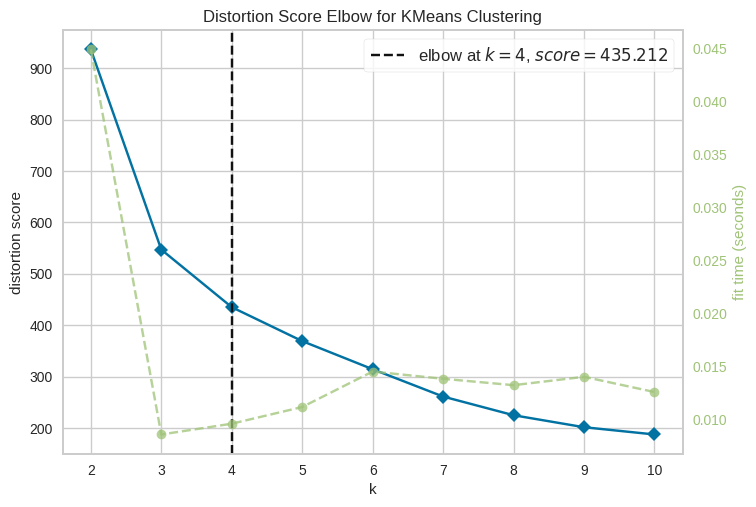

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [15]:
# importer KELbowVisualizer
from yellowbrick.cluster import KElbowVisualizer
# Instantier le modèle kmeans
kmeans_model = KMeans(init = 'random', max_iter=500)
# Instantier KELbowVisualizer
Elbow_M = KElbowVisualizer(kmeans_model, k=10)
# Entrainement
Elbow_M.fit(x)
# Visualiser l'elbow
Elbow_M.show()

#### <font color = "bisque"> Appliquer Kmeans en utilisant le k optimal

In [16]:
# Initier le modèle
KMeans_model = KMeans(n_clusters = 4, init = 'random', max_iter=500)
# Entrainer le modèle
KMeans_model.fit(x)


KMeans(init='random', max_iter=500, n_clusters=4)

#### <font color = "bisque"> Prédiction la partition

In [17]:
# Prediction de la partition(l'ensemble des classes) de X
KMeans_partition = KMeans_model.predict(x)
# Afficher la partition
KMeans_partition

array([2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 3, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2, 2, 3,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3,
       3], dtype=int32)

In [18]:
# Nombre d'observations dans chaque classe
val_cluster = pd.Series(KMeans_partition).value_counts()
val_cluster


,count
3,69
2,54
0,47
1,29


In [19]:
# Function de visualisation du diagramme en barre des nombres d'observations.
def bar_plot(val):
  fig = px.bar(x = val.index.astype(str), y = val.values, color = val.index.astype(str), text_auto = True)
  fig.show()

In [20]:
# Barplot des nombres d'observations
bar_plot(val_cluster)

#### <font color = "bisque"> Visualiser les classes prédictes par Kmeans

In [21]:
# Function de visualisuation des classes
def scatter_plot(New_df,Pred):
  fig = px.scatter(New_df, x='PC 1', y='PC 2', color=Pred.astype(str))
  fig.show()

In [22]:
# Visualiser les classes
scatter_plot(df_pca,KMeans_partition)

<font color = "bisque">Indice de silhouette value de la partition du Kmeans

In [23]:
# Importer silhouette score
from sklearn.metrics import silhouette_score
# Indice de Silhouette value
sil_Kmeans = silhouette_score(x, KMeans_partition)
print(f"La silhouette est : {sil_Kmeans: .2f}")

La silhouette est :  0.42


In [24]:
# Les graines de chaque classes
clusters_list = []
for i in range (4):
  clusters_list.append(list(df.index[KMeans_partition == i]))



In [25]:
# Afficher les graines de la classe 0
clusters_list[0]


['Graine 70',
 'Graine 74',
 'Graine 75',
 'Graine 78',
 'Graine 79',
 'Graine 80',
 'Graine 81',
 'Graine 82',
 'Graine 83',
 'Graine 84',
 'Graine 85',
 'Graine 86',
 'Graine 87',
 'Graine 88',
 'Graine 89',
 'Graine 90',
 'Graine 91',
 'Graine 93',
 'Graine 94',
 'Graine 95',
 'Graine 96',
 'Graine 98',
 'Graine 99',
 'Graine 100',
 'Graine 101',
 'Graine 102',
 'Graine 104',
 'Graine 105',
 'Graine 106',
 'Graine 107',
 'Graine 108',
 'Graine 109',
 'Graine 110',
 'Graine 111',
 'Graine 112',
 'Graine 113',
 'Graine 114',
 'Graine 115',
 'Graine 116',
 'Graine 117',
 'Graine 119',
 'Graine 121',
 'Graine 122',
 'Graine 123',
 'Graine 124',
 'Graine 126',
 'Graine 127']

### <font color='gold'> CAH

In [26]:
# Importer linkage et dendrogram
from scipy.cluster.hierarchy import  linkage, dendrogram

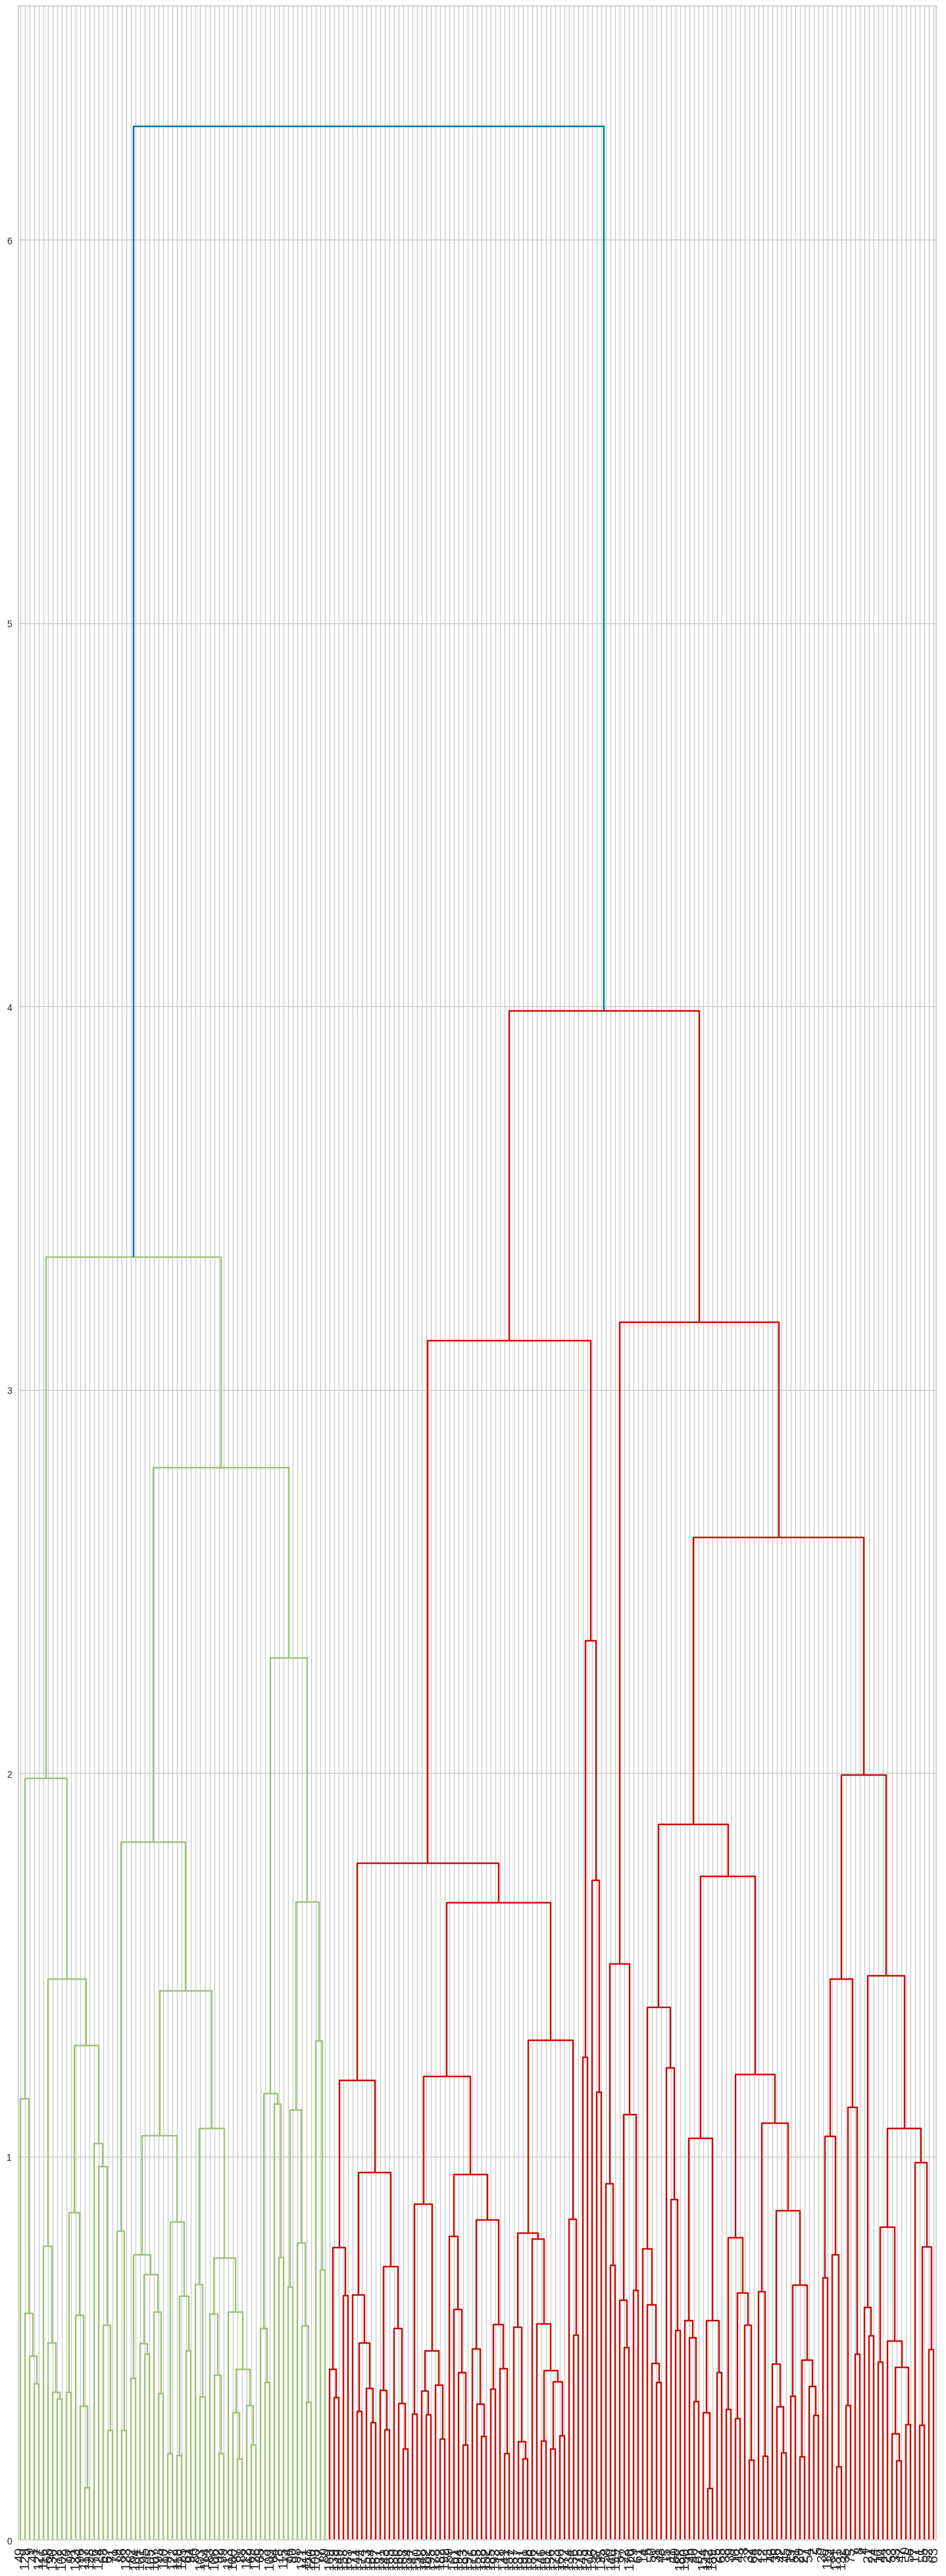

In [27]:
# Visualiser le dendrograme
import matplotlib.pyplot as plt
Z = linkage(x, 'average')# matrice des liaisons
plt.figure(figsize=(18, 50))
dendro = dendrogram(Z, leaf_font_size=15, orientation = 'top')

In [61]:
from sklearn.cluster import AgglomerativeClustering
# Initier AgglomerativeClustering
cah_model = AgglomerativeClustering(n_clusters = 2, linkage = 'average')
# Entrainer le modèle
cah_model.fit(x)

AgglomerativeClustering(linkage='average')

In [62]:
# Prédire la partition des données
pred = cah_model.fit_predict(x)
# Afficher la partition
pred[:200]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

In [63]:
# Nombre d'observations dans chaque classe
val1  = pd.Series(pred).value_counts()
val1

,count
0,132
1,67


In [64]:
# Diagramme en barre des nombres d'observations
bar_plot(val1)

In [65]:
# Visualiser les classes
scatter_plot(df_pca,pred)

In [66]:
# Silhouette score
sil_cah = silhouette_score(x,pred)
print(f'La silhouette CAH: {sil_cah: .3f}')

La silhouette CAH:  0.506


In [67]:
# Importer Gradio
import gradio as gr

NameError: name 'New_df_sans_anomalies' is not defined